In [1]:
!pip install yfinance==0.2.44 numpy pandas scikit-learn tensorflow 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.6/94.6 kB 3.1 MB/s eta 0:00:00
  Attempting uninstall: yfinance
    Found existing installation: yfinance 0.2.52
    Uninstalling yfinance-0.2.52:
      Successfully uninstalled yfinance-0.2.52


In [2]:
import yfinance as yf
import pandas as pd

# Download historical data for multiple stocks
nifty_50_tickers = [
    "RELIANCE.NS", "TCS.NS", "INFY.NS", "HDFCBANK.NS", "ICICIBANK.NS", "HINDUNILVR.NS", "ITC.NS",
    "KOTAKBANK.NS", "LT.NS", "SBIN.NS", "BHARTIARTL.NS", "BAJFINANCE.NS", "ASIANPAINT.NS",
    "AXISBANK.NS", "HCLTECH.NS", "MARUTI.NS", "SUNPHARMA.NS", "TITAN.NS", "ULTRACEMCO.NS",
    "NESTLEIND.NS", "INDUSINDBK.NS", "TATAMOTORS.NS", "ADANIENT.NS", "POWERGRID.NS", "WIPRO.NS",
    "ONGC.NS", "NTPC.NS", "BAJAJFINSV.NS", "HDFCLIFE.NS", "GRASIM.NS", "ADANIGREEN.NS",
    "COALINDIA.NS", "BPCL.NS", "TATASTEEL.NS", "JSWSTEEL.NS", "HEROMOTOCO.NS", "DIVISLAB.NS",
    "DRREDDY.NS", "EICHERMOT.NS", "BRITANNIA.NS", "APOLLOHOSP.NS", "CIPLA.NS", "BAJAJ-AUTO.NS",
    "HINDALCO.NS", "TECHM.NS", "UPL.NS", "SHREECEM.NS", "ICICIPRULI.NS", "SBILIFE.NS", "M&M.NS"
]

# Download historical adjusted closing prices
data = yf.download(stock_symbols, start="2004-01-01", end="2024-01-01")['Adj Close']

# Calculate correlation matrix
correlation_matrix = data.corr()

# Sort the correlation matrix by the 'AAPL' column
sorted_correlation = correlation_matrix['AAPL'].sort_values(ascending=False)

# Print the sorted correlation values
print(sorted_correlation)


NameError: name 'stock_symbols' is not defined

In [ ]:
import yfinance as yf
import pandas as pd
import time
from tqdm import tqdm

def restructure_stock_data(tickers, start_date='2001-01-01', end_date='2025-05-09'):
    stock_dataframes = []
    valid_tickers = []
    
    # Remove duplicates while preserving order
    seen = set()
    unique_tickers = [x for x in tickers if not (x in seen or seen.add(x))]

    for idx, ticker in enumerate(tqdm(unique_tickers, desc="Restructuring stock data")):
        try:
            # Try different symbol variations (prioritize .NS)
            symbols_to_try = [
                ticker if ticker.endswith('.NS') else f"{ticker}.NS",
                ticker.replace('.NS', '')
            ]
            
            data = None
            for symbol in symbols_to_try:
                try:
                    temp_data = yf.download(
                        symbol, 
                        start=start_date, 
                        end=end_date, 
                        progress=False,
                        auto_adjust=True
                    )
                    if not temp_data.empty:
                        data = temp_data
                        break
                except Exception as e:
                    continue
            
            if data is None or data.empty:
                print(f"\nSkipping {ticker} - no data available")
                continue

            # Prepare the data structure in the desired format
            stock_label = f'Stock{idx + 1}'
            data = data[['Open', 'Close', 'Volume']].rename(columns={
                'Open': f'Open_{stock_label}',
                'Close': f'Close_{stock_label}',
                'Volume': f'Volume_{stock_label}'
            })

            # Create label (1 if next day's open > current day's close, else 0)
            data[f'Label_{stock_label}'] = (data[f'Open_{stock_label}'].shift(-1) > data[f'Close_{stock_label}']).astype(int)

            stock_dataframes.append(data)
            valid_tickers.append(ticker)
            
            # API rate limiting
            time.sleep(0.5)
            
        except Exception as e:
            print(f"\nError processing {ticker}: {str(e)}")
            continue

    if not valid_tickers:
        print("\nNo valid stock data found after filtering.")
        return pd.DataFrame(), []

    # Merge all dataframes
    merged_data = pd.concat(stock_dataframes, axis=1)
    
    # Remove duplicate columns (in case any symbols resolved to same ticker)
    merged_data = merged_data.loc[:,~merged_data.columns.duplicated()]
    
    # Forward fill missing values (only for existing values)
    merged_data.fillna(method='ffill', inplace=True)
    
    # Drop rows where all values are NA
    merged_data.dropna(how='all', inplace=True)
    
    # Sort columns for better organization
    merged_data.sort_index(axis=1, inplace=True)

    print(f"\nFinal data shape: {merged_data.shape}")
    print(f"Time period: {merged_data.index[0].date()} to {merged_data.index[-1].date()}")
    
    return merged_data, valid_tickers

# Your tickers list
tickers =  [
    'ADANIPORTS.NS', 'ASIANPAINT.NS', 'AXISBANK.NS', 'BAJAJ-AUTO.NS', 'BAJFINANCE.NS',
    'BHARTIARTL.NS', 'BPCL.NS', 'BRITANNIA.NS', 'CIPLA.NS', 'COALINDIA.NS',
    'DIVISLAB.NS', 'DRREDDY.NS', 'EICHERMOT.NS', 'GAIL.NS', 'GRASIM.NS',
    'HCLTECH.NS', 'HDFCBANK.NS', 'HEROMOTOCO.NS', 'HINDALCO.NS',
    'HINDPETRO.NS', 'HINDUNILVR.NS', 'ICICIBANK.NS', 'INDUSINDBK.NS', 'INFY.NS',
    'ITC.NS', 'JSWSTEEL.NS', 'KOTAKBANK.NS', 'LT.NS', 'M&M.NS', 'MARUTI.NS',
    'NTPC.NS', 'ONGC.NS', 'POWERGRID.NS', 'RELIANCE.NS', 'SBIN.NS', 'SHREECEM.NS',
    'SUNPHARMA.NS', 'TATACONSUM.NS', 'TATAMOTORS.NS', 'TATAPOWER.NS', 'TCS.NS',
    'TECHM.NS', 'TITAN.NS', 'ULTRACEMCO.NS', 'UPL.NS', 'WIPRO.NS'
]

# Run the function
restructured_data, valid_tickers = restructure_stock_data(tickers)

# Print result summary
if not restructured_data.empty:
    print("\nFirst 3 rows of data:")
    print(restructured_data.head(3))
    print(f"\nValid stocks used ({len(valid_tickers)}):")
    print(valid_tickers)
else:
    print("\nNo valid data to show. Possible solutions:")
    print("1. Check your internet connection")
    print("2. Try using a VPN (some ISPs block Yahoo Finance)")
    print("3. Verify symbols on Yahoo Finance website")
    print("4. Try with fewer stocks first")

# Save to CSV for inspection
if not restructured_data.empty:
    restructured_data.to_csv('restructured_stock_data.csv')
    print("\nData saved to 'restructured_stock_data.csv'")

data=restructured_data.dropna()
data.shape

In [462]:
import pandas as pd
import time
from tqdm import tqdm

data=pd.read_csv("/kaggle/input/stckdata/stockdata.csv")
data.dropna(inplace=True)
data.drop(['Price'], axis=1, inplace=True)
data=data.reset_index()
data.drop(['index'], axis=1, inplace=True)

In [463]:
data.head()

,Open_Stock1,Close_Stock1,Volume_Stock1,Label_Stock1,Open_Stock2,Close_Stock2,Volume_Stock2,Label_Stock2,Open_Stock3,Close_Stock3,...,Volume_Stock45,Label_Stock45,Open_Stock46,Close_Stock46,Volume_Stock46,Label_Stock46,Open_Stock47,Close_Stock47,Volume_Stock47,Label_Stock47
0,148.88042684475403,149.06536865234375,835546,1.0,239.75036869773373,236.5525665283203,1016060,1.0,285.11825344179863,283.95989990234375,...,240228,1.0,125.50902516186422,127.82435607910156,4348491,1.0,76.04738002947454,75.6576156616211,3697295,1.0
1,150.26747552117655,149.25027465820312,613082,1.0,238.68005590838789,243.46340942382812,575620,1.0,286.6443460070744,286.0743713378906,...,334545,1.0,129.17747418592734,126.53137969970703,2755053,0.0,76.48046144140555,74.69620513916016,3652468,1.0
2,150.26749668209504,150.03631591796875,601933,1.0,243.67216031877726,244.755859375,378020,0.0,285.90889751607847,287.2510986328125,...,563045,1.0,126.08035635929913,124.24613952636719,2790532,1.0,74.95602318607811,74.77413177490234,4901358,1.0
3,150.26747494037238,147.86318969726562,423032,1.0,244.72030555011284,244.04965209960938,460770,0.0,288.1152592090845,283.77606201171875,...,310985,1.0,124.8775797625399,124.6670913696289,1809577,0.0,75.35444904849146,75.6229476928711,5237801,0.0
4,148.92662773093423,143.70193481445312,1955709,1.0,244.049645905535,235.46888732910156,1187270,1.0,284.2541139910849,279.9149169921875,...,545462,0.0,121.02874332729519,123.04337310791016,887742,0.0,75.52768079879822,74.25444793701172,1795396,1.0


In [464]:
L=[4,13,29,30,2,5,8,21,38,43,9,37,11,12,41,42,16,24,46]


In [465]:
def filter_stock_columns_by_suffix(df: pd.DataFrame, stock_ids: list[int]) -> pd.DataFrame:
    """
    Keep only columns that end with a stock number from the given list.
    
    Parameters:
        df (pd.DataFrame): Original DataFrame with all stock columns.
        stock_ids (list[int]): List of stock IDs to retain (e.g., [1, 4]).
        
    Returns:
        pd.DataFrame: Filtered DataFrame with only the specified stock columns.
    """
    # Convert IDs to string for matching suffixes
    stock_suffixes = [f"Stock{i}" for i in stock_ids]

    # Keep only columns that end with one of the specified suffixes
    filtered_columns = [col for col in df.columns if any(col.endswith(suffix) for suffix in stock_suffixes)]
    
    return df[filtered_columns]
data=filter_stock_columns_by_suffix(data,L)


In [466]:
data.columns

Index(['Open_Stock2', 'Close_Stock2', 'Volume_Stock2', 'Label_Stock2',
       'Open_Stock4', 'Close_Stock4', 'Volume_Stock4', 'Label_Stock4',
       'Open_Stock5', 'Close_Stock5', 'Volume_Stock5', 'Label_Stock5',
       'Open_Stock8', 'Close_Stock8', 'Volume_Stock8', 'Label_Stock8',
       'Open_Stock9', 'Close_Stock9', 'Volume_Stock9', 'Label_Stock9',
       'Open_Stock11', 'Close_Stock11', 'Volume_Stock11', 'Label_Stock11',
       'Open_Stock12', 'Close_Stock12', 'Volume_Stock12', 'Label_Stock12',
       'Open_Stock13', 'Close_Stock13', 'Volume_Stock13', 'Label_Stock13',
       'Open_Stock16', 'Close_Stock16', 'Volume_Stock16', 'Label_Stock16',
       'Open_Stock21', 'Close_Stock21', 'Volume_Stock21', 'Label_Stock21',
       'Open_Stock24', 'Close_Stock24', 'Volume_Stock24', 'Label_Stock24',
       'Open_Stock29', 'Close_Stock29', 'Volume_Stock29', 'Label_Stock29',
       'Open_Stock30', 'Close_Stock30', 'Volume_Stock30', 'Label_Stock30',
       'Open_Stock37', 'Close_Stock37', 'Volu

In [467]:
data.shape

(3433, 76)

Stock Number to Ticker Mapping:

Stock1: ADANIPORTS.NS

Stock2: ASIANPAINT.NS

Stock3: AXISBANK.NS

Stock4: BAJAJ-AUTO.NS

Stock5: BAJFINANCE.NS

Stock6: BHARTIARTL.NS

Stock7: BPCL.NS

Stock8: BRITANNIA.NS

Stock9: CIPLA.NS

Stock10: COALINDIA.NS

Stock11: DIVISLAB.NS

Stock12: DRREDDY.NS

Stock13: EICHERMOT.NS

Stock14: GAIL.NS

Stock15: GRASIM.NS

Stock16: HCLTECH.NS

Stock17: HDFCBANK.NS

Stock18: HEROMOTOCO.NS

Stock19: HINDALCO.NS

Stock20: HINDPETRO.NS

Stock21: HINDUNILVR.NS

Stock22: ICICIBANK.NS

Stock23: INDUSINDBK.NS

Stock24: INFY.NS

Stock25: ITC.NS

Stock26: JSWSTEEL.NS

Stock27: KOTAKBANK.NS

Stock28: LT.NS

Stock29: M&M.NS

Stock30: MARUTI.NS

Stock31: NTPC.NS

Stock32: ONGC.NS

Stock33: POWERGRID.NS

Stock34: RELIANCE.NS

Stock35: SBIN.NS

Stock36: SHREECEM.NS

Stock37: SUNPHARMA.NS

Stock38: TATACONSUM.NS

Stock39: TATAMOTORS.NS

Stock40: TATAPOWER.NS

Stock41: TCS.NS

Stock42: TECHM.NS

Stock43: TITAN.NS

Stock44: ULTRACEMCO.NS

Stock45: UPL.NS

Stock46: WIPRO.NS


In [468]:
import pandas as pd
import numpy as np

def convert_categorical_to_numerical(df):
    """
    Convert categorical data to numerical values with specific handling:
    - Columns starting with 'Label_' are converted to integers
    - All other columns are converted to decimals (floats)
    
    Parameters:
    df (pd.DataFrame): Input DataFrame with categorical data
    
    Returns:
    pd.DataFrame: DataFrame with converted numerical values
    """
    # Create a copy to avoid modifying the original DataFrame
    converted_df = df.copy()
    
    # Identify label columns (columns starting with 'Label_')
    label_cols = [col for col in df.columns if col.startswith('Label_')]
    
    # Convert label columns to integers
    for col in label_cols:
        converted_df[col] = pd.to_numeric(converted_df[col], errors='coerce').astype('int32')  # Int64 handles NaN
    
    # Convert all other columns to decimals (floats)
    other_cols = [col for col in df.columns if col not in label_cols]
    for col in other_cols:
        converted_df[col] = pd.to_numeric(converted_df[col], errors='coerce').astype('float32')
    
    return converted_df

# Example usage:
# Assuming your DataFrame is called 'stock_data'
data = convert_categorical_to_numerical(data)

In [469]:
data.dtypes

Open_Stock2       float32
Close_Stock2      float32
Volume_Stock2     float32
Label_Stock2        int32
Open_Stock4       float32
                   ...   
Label_Stock43       int32
Open_Stock46      float32
Close_Stock46     float32
Volume_Stock46    float32
Label_Stock46       int32
Length: 76, dtype: object

In [470]:
# Scale the features using MinMaxScaler
import numpy as np
import pandas as pd
import yfinance as yf
    
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Input, Concatenate, Bidirectional, TimeDistributed
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from tensorflow.keras.callbacks import EarlyStopping



In [471]:
import pandas as pd
from sklearn.preprocessing import StandardScaler  # Alternatively, use MinMaxScaler

# Assuming 'data' is your DataFrame

# Identify feature columns (exclude 'Label_' columns)
feature_columns = [col for col in data.columns if 'Label_' not in col]

# Create a copy of the DataFrame to avoid modifying the original
data_scaled = data.copy()

# Initialize the scaler
scaler = MinMaxScaler()  # Alternatively, use MinMaxScaler()

# Apply the scaler to the feature columns
data_scaled[feature_columns] = scaler.fit_transform(data[feature_columns])

# Now, data_scaled contains the scaled features and the original 'Label_' columns remain unchanged
print(data_scaled.head())
# data=data_scaled

   Open_Stock2  Close_Stock2  Volume_Stock2  Label_Stock2  Open_Stock4  \
0     0.009041      0.007095       0.054285             1     0.023610   
1     0.008716      0.009200       0.030754             1     0.025549   
2     0.010233      0.009593       0.020196             0     0.024377   
3     0.010551      0.009378       0.024617             0     0.024908   
4     0.010347      0.006765       0.063432             1     0.024200   

   Close_Stock4  Volume_Stock4  Label_Stock4  Open_Stock5  Close_Stock5  ...  \
0      0.023905       0.054479             1     0.002504      0.002958  ...   
1      0.023322       0.042846             1     0.002799      0.002945  ...   
2      0.023884       0.033547             1     0.002699      0.003019  ...   
3      0.021801       0.032638             1     0.002777      0.002953  ...   
4      0.021401       0.024289             0     0.002800      0.002798  ...   

   Volume_Stock42  Label_Stock42  Open_Stock43  Close_Stock43  Volume_Stoc

In [472]:
import numpy as np
# Function to create datasets
def create_dataset(data1,data2, time_step, feature_columns, label_columns):
    X, y = [], []
    for i in range(len(data2) - time_step):
        # Append only feature columns for X
        X.append(data1[i:(i + time_step), feature_columns])
        # Append only label columns for y at the end of each sequence
        y.append(data2[i + time_step - 1, label_columns])
    return np.array(X), np.array(y)

# Define the time step
time_step = 60

# Get the indices for feature and label columns
feature_columns = [i for i, col in enumerate(data.columns) if 'Label_' not in col]
label_columns = [i for i, col in enumerate(data.columns) if 'Label_' in col]
data.dropna(inplace=True)
# Create the dataset
X, y = create_dataset(data_scaled.values,data.values, time_step, feature_columns, label_columns)
print(y.shape)

(3373, 19)


In [473]:
# # print(X)
# for i in data.columns:
#     print(i," ",data[i].value_counts())
#     print(data[i].isnull().sum())

In [474]:
# Split data into training, validation, and testing sets
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)
test_size = len(X) - train_size - val_size

X_train, X_val, X_test = X[:train_size], X[train_size:train_size + val_size], X[train_size + val_size:]
y_train, y_val, y_test = y[:train_size], y[train_size:train_size + val_size], y[train_size + val_size:]

In [475]:
import tensorflow as tf
def quantile_loss(q):
    def loss(y_true, y_pred):
        err = y_true - y_pred
        return tf.reduce_mean(tf.where(err >= 0, q * err, (q - 1) * err))
    return loss


In [476]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GRU, GlobalAveragePooling1D, MultiHeadAttention, LSTM, Attention, Dense, Dropout, Conv1D, MaxPooling1D, Bidirectional, TimeDistributed, Concatenate
from tensorflow.keras.optimizers import Adam
num_stocks=len(L)

n = int((num_stocks) )

# Input layer
input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]))

# Encoding layer to reduce dimensions
x_encoded = TimeDistributed(Dense(n, activation='linear'))(input_layer)
# x_encoded = TimeDistributed(Dense(8, activation='relu'))(x_encoded)

# LSTM and GRU branches
x1 = LSTM(64, return_sequences=False)(input_layer)
x1 = Dropout(0.2)(x1)

x2 = GRU(64, return_sequences=False)(input_layer)
x2 = Dropout(0.2)(x2)

# Concatenate branches
x = Concatenate()([x1, x2])
# x = LSTM(48, return_sequences=False)(x)
x = Dropout(0.2)(x)
x = Dense(46, activation='relu')(x)

# Output layers for binary classification of each stock
outputs = [Dense(1, activation='sigmoid', name=f'stock_{i+1}_output')(x) for i in range(num_stocks)]

# Define the model
model1 = Model(inputs=input_layer, outputs=outputs)

# Use binary cross-entropy loss for binary classification
losses = {f'stock_{i+1}_output': 'binary_crossentropy' for i in range(num_stocks)}

# Define metrics for binary classification
metrics = {f'stock_{i+1}_output': ['accuracy'] for i in range(num_stocks)}

# Define equal loss weights for each stock
loss_weights = {f'stock_{i+1}_output': 1/num_stocks for i in range(num_stocks)}

# Compile the model
model1.compile(
    optimizer=Adam(learning_rate=0.0001, clipnorm=1.0),
    loss=losses,
    metrics=metrics,
    loss_weights=loss_weights)

model1.summary()


Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_19            │ (None, 60, 57)         │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_19 (LSTM)            │ (None, 64)             │         31,232 │ input_layer_19[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ gru_19 (GRU)              │ (None, 64)             │         23,616 │ input_layer_19[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_57 (Dropout)      │ (None, 64)             │              0 │ lstm_19[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_58 (Dropout)      │ (None, 64)             │              0 │ gru_19[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_19            │ (None, 128)            │              0 │ dropout_57[0][0],      │
│ (Concatenate)             │                        │                │ dropout_58[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_59 (Dropout)      │ (None, 128)            │              0 │ concatenate_19[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_39 (Dense)          │ (None, 46)             │          5,934 │ dropout_59[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stock_1_output (Dense)    │ (None, 1)              │             47 │ dense_39[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stock_2_output (Dense)    │ (None, 1)              │             47 │ dense_39[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stock_3_output (Dense)    │ (None, 1)              │             47 │ dense_39[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stock_4_output (Dense)    │ (None, 1)              │             47 │ dense_39[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stock_5_output (Dense)    │ (None, 1)              │             47 │ dense_39[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stock_6_output (Dense)    │ (None, 1)              │             47 │ dense_39[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stock_7_output (Dense)    │ (None, 1)              │             47 │ dense_39[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stock_8_output (Dense)    │ (None, 1)              │             47 │ dense_39[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stock_9_output (Dense)    │ (None, 1)              │             47 │ dense_39[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stock_10_output (Dense)   │ (None, 1)              │             47 │ dense_39[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stock_11_output (Dens

 Total params: 61,675 (240.92 KB)

 Trainable params: 61,675 (240.92 KB)

 Non-trainable params: 0 (0.00 B)

In [477]:
# from tensorflow.keras.models import Model
# from tensorflow.keras.layers import Input, GRU, GlobalAveragePooling1D, MultiHeadAttention, LSTM, Dense, Dropout, Conv1D, MaxPooling1D, Bidirectional, TimeDistributed, Concatenate
# from tensorflow.keras.losses import Huber
# from tensorflow.keras.optimizers import Adam

# n = int(len(stock_symbols) / 4)

# # Input layer
# input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]))
# x_encoded = TimeDistributed(Dense(n, activation='linear'))(input_layer)
# # x_encoded = TimeDistributed(Dense(8, activation='relu'))(x_encoded)
# # Convolutional and LSTM layers
# x = Conv1D(filters=64, kernel_size=7, activation='relu')(x_encoded)
# x = MaxPooling1D(pool_size=4)(x)

# x1 = LSTM(96, return_sequences=True)(x_encoded)
# x1 = Dropout(0.2)(x1)

# x2 = GRU(96, return_sequences=True)(x_encoded)
# x2 = Dropout(0.2)(x2)

# # Concatenate LSTM and GRU branches
# x = Concatenate()([x1, x2])

# # Multi-Head Attention
# # x = MultiHeadAttention(num_heads=3, key_dim=16)(x, x,x)

# # Separate LSTM and Dense layers for each output branch
# outputs = []
# for i in range(num_stocks):
#     branch = LSTM(16, return_sequences=False)(x)  # LSTM layer for each branch
#     branch = Dropout(0.2)(branch)
#     branch = Dense(8, activation='relu')(branch)
#     output = Dense(1, name=f'stock_{i+1}_output')(branch)  # Output for each stock
#     outputs.append(output)

# # Define the model with multiple outputs
# model2 = Model(inputs=input_layer, outputs=outputs)

# # Define the loss for each output using Huber loss
# losses = {f'stock_{i+1}_output': Huber() for i in range(num_stocks)}

# # Define the metrics for each stock's output (e.g., 'mse' for each stock)
# metrics = {f'stock_{i+1}_output': ['mse'] for i in range(num_stocks)}

# # Define the loss weights for each stock to give equal importance
# loss_weights = {f'stock_{i+1}_output': 1 / num_stocks for i in range(num_stocks)}

# # Compile the model with the adjusted losses, metrics, and loss weights
# model2.compile(
#     optimizer=Adam(learning_rate=0.001),
#     loss=losses,
#     metrics=metrics,
#     loss_weights=loss_weights
# )

# model2.summary()


In [478]:
# history2 = model2.fit(
#     X_train,
#     y_train_stocks,
#     epochs=50,
#     batch_size=16,
#     validation_data=(X_val, y_val_stocks),
#     shuffle=True,
#     callbacks=[early_stopping]
# )

In [479]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_val = X_val.astype('float32')

In [480]:
from tensorflow.keras.callbacks import EarlyStopping
# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Separate target values for each stock output to match the model's expected output format
y_train_stocks = [y_train[:, i] for i in range(num_stocks)]
y_val_stocks = [y_val[:, i] for i in range(num_stocks)]
y_test_stocks = [y_test[:, i] for i in range(num_stocks)]

# Fit the model
history1 = model1.fit(
    X_train,
    y_train_stocks,                  # List of targets for each output
    epochs=50,
    batch_size=16,
    validation_data=(X_val, y_val_stocks),  # Validation targets in list format
    shuffle=True,
    callbacks=[early_stopping]
)


Epoch 1/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 36s 70ms/step - loss: 0.6899 - stock_10_output_accuracy: 0.6130 - stock_10_output_loss: 0.0357 - stock_11_output_accuracy: 0.5568 - stock_11_output_loss: 0.0362 - stock_12_output_accuracy: 0.6457 - stock_12_output_loss: 0.0347 - stock_13_output_accuracy: 0.5279 - stock_13_output_loss: 0.0363 - stock_14_output_accuracy: 0.5322 - stock_14_output_loss: 0.0361 - stock_15_output_accuracy: 0.5855 - stock_15_output_loss: 0.0359 - stock_16_output_accuracy: 0.6015 - stock_16_output_loss: 0.0358 - stock_17_output_accuracy: 0.4407 - stock_17_output_loss: 0.0373 - stock_18_output_accuracy: 0.5990 - stock_18_output_loss: 0.0359 - stock_19_output_accuracy: 0.3616 - stock_19_output_loss: 0.0380 - stock_1_output_accuracy: 0.5048 - stock_1_output_loss: 0.0364 - stock_2_output_accuracy: 0.4445 - stock_2_output_loss: 0.0371 - stock_3_output_accuracy: 0.4784 - stock_3_output_loss: 0.0367 - stock_4_output_accuracy: 0.4998 - stock_4_output_loss: 0.0366 - stock_5_outpu

In [481]:
# y_pred_stocks

In [483]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Function to evaluate metrics and store results in a DataFrame for binary classification
def evaluate_metrics_table(y_test, y_pred, stock_name, metrics_df):
    # Apply threshold at 0.5 for binary classification
    y_pred_class = y_pred > 0.5
    accuracy = accuracy_score(y_test, y_pred_class)
    precision = precision_score(y_test, y_pred_class, zero_division=0)
    recall = recall_score(y_test, y_pred_class, zero_division=0)
    f1 = f1_score(y_test, y_pred_class)
    
    # Create a temporary DataFrame to hold the new row of results
    temp_df = pd.DataFrame({
        'Stock': [stock_name],
        'Accuracy': [accuracy],
        'Precision': [precision],
        'Recall': [recall],
        'F1-score': [f1]
    })
    # Concatenate the new row with the existing metrics_df
    metrics_df = pd.concat([metrics_df, temp_df], ignore_index=True)
    
    return metrics_df

# Initialize an empty DataFrame to store metrics for each stock
metrics_df = pd.DataFrame(columns=['Stock', 'Accuracy', 'Precision', 'Recall', 'F1-score'])

# Make predictions for the test set
y_pred_stocks = model1.predict(X_test)

# Evaluate metrics for each stock and store them in the DataFrame
for i in range(num_stocks):
    metrics_df = evaluate_metrics_table(y_test_stocks[i], y_pred_stocks[i], f'Stock_{i+1}', metrics_df)

# Display the metrics as a table
print("Model-1 Performance Metrics")
print(metrics_df)


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Model-1 Performance Metrics
       Stock  Accuracy  Precision  Recall  F1-score
0    Stock_1  0.625247   0.625247     1.0  0.769417
1    Stock_2  0.646943   0.646943     1.0  0.785629
2    Stock_3  0.648915   0.648915     1.0  0.787081
3    Stock_4  0.664694   0.664694     1.0  0.798578
4    Stock_5  0.717949   0.717949     1.0  0.835821
5    Stock_6  0.639053   0.639053     1.0  0.779783
6    Stock_7  0.680473   0.680473     1.0  0.809859
7    Stock_8  0.650888   0.650888     1.0  0.788530
8    Stock_9  0.635108   0.635108     1.0  0.776840
9   Stock_10  0.696252   0.696252     1.0  0.820930
10  Stock_11  0.644970   0.644970     1.0  0.784173
11  Stock_12  0.666667   0.666667     1.0  0.800000
12  Stock_13  0.684418   0.684418     1.0  0.812646
13  Stock_14  0.641026   0.641026     1.0  0.781250
14  Stock_15  0.664694   0.664694     1.0  0.798578
15  Stock_16  0.783037   0.783037     1.0  0.878319
16  Stock_17  0.562130   0.562130     1.0  0.719

/tmp/ipykernel_31/1699537929.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df = pd.concat([metrics_df, temp_df], ignore_index=True)


In [484]:
# Descriptive statistics for accuracy
accuracy_stats = metrics_df['Accuracy'].describe()
print("Accuracy Distribution Summary:")
print(accuracy_stats)


Accuracy Distribution Summary:
count    19.000000
mean      0.662203
std       0.046753
min       0.562130
25%       0.640039
50%       0.650888
75%       0.682446
max       0.783037
Name: Accuracy, dtype: float64


In [485]:
# Descriptive statistics for accuracy
accuracy_stats = metrics_df['F1-score'].describe()
print("F-1 Distribution Summary:")
print(accuracy_stats)


F-1 Distribution Summary:
count    19.000000
mean      0.795886
std       0.033504
min       0.719697
25%       0.780517
50%       0.788530
75%       0.811253
max       0.878319
Name: F1-score, dtype: float64


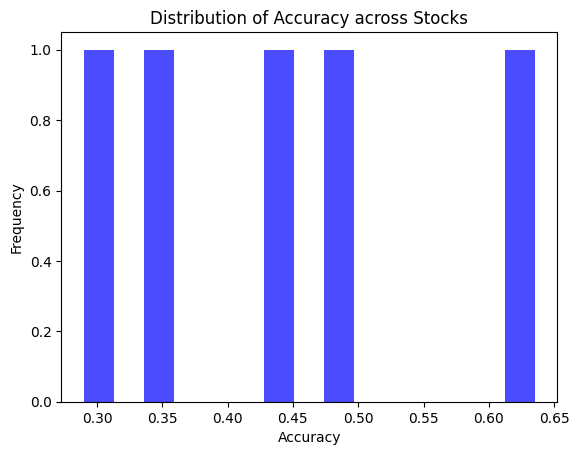

In [323]:
import matplotlib.pyplot as plt

plt.hist(metrics_df['Accuracy'], bins=15, alpha=0.7, color='blue')
plt.title('Distribution of Accuracy across Stocks')
plt.xlabel('Accuracy')
plt.ylabel('Frequency')
plt.show()


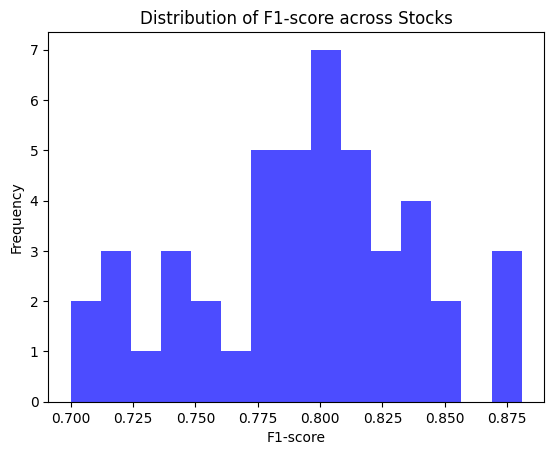

In [112]:
import matplotlib.pyplot as plt

plt.hist(metrics_df['F1-score'], bins=15, alpha=0.7, color='blue')
plt.title('Distribution of F1-score across Stocks')
plt.xlabel('F1-score')
plt.ylabel('Frequency')
plt.show()


In [113]:
from sklearn.metrics import roc_auc_score, average_precision_score

auc_roc = roc_auc_score(y_test, y_pred_class)
auc_pr = average_precision_score(y_test, y_pred_class)

print(f"AUC-ROC: {auc_roc}")
print(f"AUC-PR: {auc_pr}")


NameError: name 'y_pred_class' is not defined

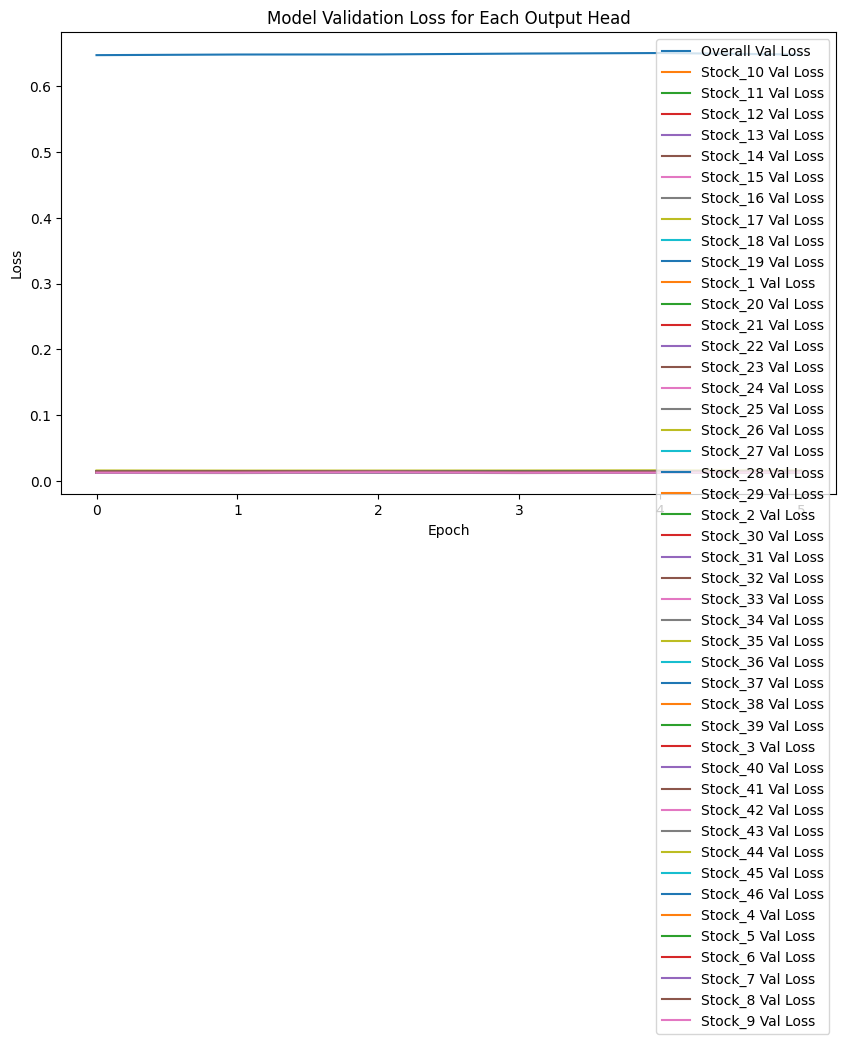

In [116]:
import matplotlib.pyplot as plt

# Extract keys related to validation loss from the history
val_loss_keys = [key for key in history1.history.keys() if 'val_' in key and 'loss' in key]

# Initialize the plot
plt.figure(figsize=(10, 6))

# Plot overall validation loss first if present
if 'val_loss' in history1.history:
    plt.plot(history1.history['val_loss'], label='Overall Val Loss')

# Loop through each validation loss key and plot the loss for each stock output
for key in val_loss_keys:
    if key != 'val_loss':  # Exclude the overall validation loss, if plotted already
        stock_label = key.split('_output_')[0].replace('val_', '').title()  # Dynamically create stock labels
        plt.plot(history1.history[key], label=f'{stock_label} Val Loss')

# Customize the plot
plt.title('Model Validation Loss for Each Output Head')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [49]:
# Make predictions
predictions = model1.predict(X_test)
print(predictions)
# Initialize the figure for plotting
plt.figure(figsize=(15, 5 * num_stocks))  # Adjust the height dynamically based on the number of stocks

# Loop through each stock and plot
for i in range(num_stocks):
    plt.subplot(num_stocks, 1, i + 1)  # Create subplot for each stock dynamically
    plt.plot(y_test_stocks[i], label=f'Actual Stock {i+1}', color='blue')
    plt.plot(predictions[i], label=f'Predicted Stock {i+1}', color='orange')
    plt.title(f'Stock {i+1}: Actual vs Predicted')
    plt.xlabel('Time Step')
    plt.ylabel('Stock Price')
    plt.legend()

# Adjust layout
plt.tight_layout()
plt.show()


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
[array([[0.6089213 ],
       [0.60906684],
       [0.6096592 ],
       [0.6100652 ],
       [0.6103927 ],
       [0.61039865],
       [0.60982907],
       [0.60919017],
       [0.6083455 ],
       [0.607721  ],
       [0.60717374],
       [0.6067251 ],
       [0.60640925],
       [0.6068321 ],
       [0.6067129 ],
       [0.6068531 ],
       [0.60769063],
       [0.6092333 ],
       [0.6099977 ],
       [0.6102279 ],
       [0.61043835],
       [0.61096746],
       [0.6113249 ],
       [0.6113955 ],
       [0.6144611 ],
       [0.61614656],
       [0.61708546],
       [0.6173364 ],
       [0.61750007],
       [0.61719   ],
       [0.6173275 ],
       [0.61718315],
       [0.6165341 ],
       [0.61606634],
       [0.6157491 ],
       [0.61557883],
       [0.6148573 ],
       [0.6138041 ],
       [0.6142165 ],
       [0.614492  ],
       [0.6145637 ],
       [0.61457646],
       [0.61462134],
       [0.6145921 ],
       [0.6149852 ],
       [0.6151

NameError: name 'plt' is not defined

In [119]:
model1.save("lstm_46_final.h5")

In [ ]:
# Inspect model weights for NaNs
for layer in model1.layers:
    weights = layer.get_weights()
    if any(np.isnan(w).any() for w in weights):
        print(f"NaNs found in weights of layer: {layer.name}")
